# Insurance Cost Forecasting Model

## Import Libs

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [53]:
# Deep learning (PyTorch)
import torch
from torch import nn

### Import Scaled Dataset

In [54]:
# Import scaled dataset
df = pd.read_csv("datasets/transformed_data.csv")
df

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,False,-0.453320,0,True,16884.92400,False,False,False,True
1,-1.509965,True,0.509621,1,False,1725.55230,False,False,True,False
2,-0.797954,True,0.383307,3,False,4449.46200,False,False,True,False
3,-0.441948,True,-1.305531,0,False,21984.47061,False,True,False,False
4,-0.513149,True,-0.292556,0,False,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,True,0.050297,3,False,10600.54830,False,True,False,False
1334,-1.509965,False,0.206139,0,False,2205.98080,True,False,False,False
1335,-1.509965,False,1.014878,0,False,1629.83350,False,False,True,False
1336,-1.296362,False,-0.797813,0,False,2007.94500,False,False,False,True


## Train Test data splitting

In [55]:
features = ["age", "sex", "bmi", "children", "smoker", "region_northeast", "region_northwest", "region_southeast", "region_southwest"]
X = df[features]
y = df["charges"]

X.head(), y.head()

(        age    sex       bmi  children  smoker  region_northeast  \
 0 -1.438764  False -0.453320         0    True             False   
 1 -1.509965   True  0.509621         1   False             False   
 2 -0.797954   True  0.383307         3   False             False   
 3 -0.441948   True -1.305531         0   False             False   
 4 -0.513149   True -0.292556         0   False             False   
 
    region_northwest  region_southeast  region_southwest  
 0             False             False              True  
 1             False              True             False  
 2             False              True             False  
 3              True             False             False  
 4              True             False             False  ,
 0    16884.92400
 1     1725.55230
 2     4449.46200
 3    21984.47061
 4     3866.85520
 Name: charges, dtype: float64)

In [56]:
X.shape, y.shape

((1338, 9), (1338,))

### Convert all data to Tensors

In [57]:
X.values

array([[-1.438764260264482, False, -0.4533200014601978, ..., False,
        False, True],
       [-1.5099654504939408, True, 0.5096210969173165, ..., False, True,
        False],
       [-0.7979535481993532, True, 0.3833068472153252, ..., False, True,
        False],
       ...,
       [-1.5099654504939408, False, 1.014878095725279, ..., False, True,
        False],
       [-1.2963618798055645, False, -0.797813409738354, ..., False,
        False, True],
       [1.5516857293727864, False, -0.2613879597052247, ..., True, False,
        False]], shape=(1338, 9), dtype=object)

In [58]:
# Force all boolean values to become 0s or 1s, bcz boolean values get converted to objects,
# these objects can not be converted into tensors
X = X.astype(float)
y = y.astype(float)

# Convert to numpy array then to tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)

X_tensor.shape, y_tensor.shape

(torch.Size([1338, 9]), torch.Size([1338]))

In [59]:
# Train - Test splitting

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test

(tensor([[ 0.4837,  0.0000, -1.7575,  ...,  1.0000,  0.0000,  0.0000],
         [ 0.5549,  0.0000, -1.0406,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.9109,  0.0000, -0.9520,  ...,  0.0000,  1.0000,  0.0000],
         ...,
         [ 1.3381,  1.0000, -0.9003,  ...,  0.0000,  0.0000,  0.0000],
         [-0.1571,  0.0000,  2.7784,  ...,  0.0000,  0.0000,  1.0000],
         [ 1.1245,  1.0000, -0.1252,  ...,  0.0000,  0.0000,  1.0000]]),
 tensor([[ 0.4125,  0.0000, -0.9003,  ...,  0.0000,  0.0000,  0.0000],
         [-0.2283,  0.0000, -0.1055,  ...,  1.0000,  0.0000,  0.0000],
         [ 1.7653,  0.0000, -0.6198,  ...,  1.0000,  0.0000,  0.0000],
         ...,
         [-0.0859,  1.0000, -0.4328,  ...,  0.0000,  0.0000,  0.0000],
         [ 1.0533,  0.0000,  2.7472,  ...,  0.0000,  1.0000,  0.0000],
         [ 0.8397,  0.0000,  0.5802,  ...,  0.0000,  0.0000,  1.0000]]),
 tensor([ 9193.8389,  8534.6719, 27117.9941,  ..., 11931.1250, 46113.5117,
         10214.6357]),
 tensor([ 9095.068

In [60]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([1070, 9]),
 torch.Size([268, 9]),
 torch.Size([1070]),
 torch.Size([268]))

### Visualize

In [61]:
# Define a visualization function

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plot training and testing data and compares predictions
    """

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Training data
    ax[0].scatter(X_train[:, 0], y_train, c="blue", s=10, alpha=0.8, label="Training data"), ax[0].set_title("Charges vs Age")      # for age
    ax[1].scatter(X_train[:, 2], y_train, c="blue", s=10, alpha=0.8, label="Training data"), ax[1].set_title("Charges vs BMI")     # for bmi

    # Testing data
    ax[0].scatter(X_test[:, 0], y_test, c="green", s=10, alpha=0.8, label="Testing data"), ax[0].set_title("Charges vs Age")
    ax[1].scatter(X_test[:, 2], y_test, c="green", s=10, alpha=0.8, label="Testing data"), ax[1].set_title("Charges vs BMI")

    # Plot predictions if any
    if predictions is not None:
        ax[0].scatter(X_test[:, 0], y=predictions, c="red", s=10, alpha=0.8, label="Predictions"), ax[0].set_title("Charges vs Age")
        ax[1].scatter(X_test[:, 2], y=predictions, c="red", s=10, alpha=0.8, label="Predictions"), ax[1].set_title("Charges vs BMI")

    # plt.figure(figsize=(15, 10))

    # # training data
    # plt.scatter(x=X_train, y=y_train, c="blue", s=10, alpha=0.8, label="Training data")

    # # testing data
    # plt.scatter(x=X_test, y=y_test, c="green", s=10, alpha=0.8, label="Testing data")

    # # Plot predictions if any
    # if predictions is not None:
    #     plt.scatter(x=X_test, y=predictions, c="red", s=10, alpha=0.8, label="Predictions")

    # plt.legend(props={"size": 14})

    plt.show()

In [62]:
X.shape, y.shape

((1338, 9), (1338,))

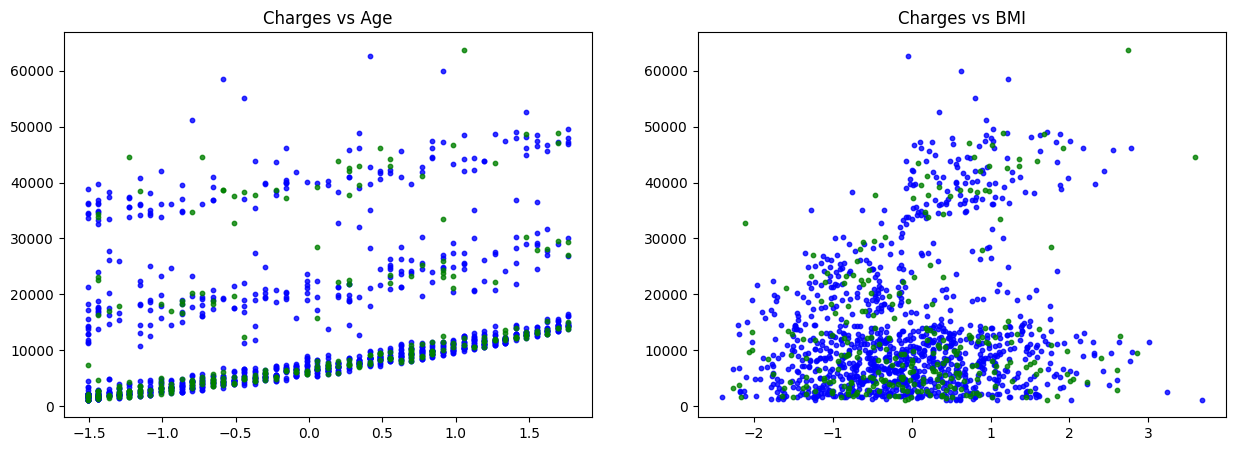

In [63]:
plot_predictions()

### Model architecture

It is a simple Linear-Regression model with multiple input features

In [64]:
X_train

tensor([[ 0.4837,  0.0000, -1.7575,  ...,  1.0000,  0.0000,  0.0000],
        [ 0.5549,  0.0000, -1.0406,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.9109,  0.0000, -0.9520,  ...,  0.0000,  1.0000,  0.0000],
        ...,
        [ 1.3381,  1.0000, -0.9003,  ...,  0.0000,  0.0000,  0.0000],
        [-0.1571,  0.0000,  2.7784,  ...,  0.0000,  0.0000,  1.0000],
        [ 1.1245,  1.0000, -0.1252,  ...,  0.0000,  0.0000,  1.0000]])

In [65]:
# Model architecture

class MultipleRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 9 input features
        self.linear = nn.Linear(in_features=9, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # No activation function for Multiple-Regression
        return self.linear(x)

In [66]:
# Instanciate model
model_V1 = MultipleRegressionModel()

In [67]:
# List model parameters
list(model_V1.parameters())

[Parameter containing:
 tensor([[ 0.2658, -0.0901, -0.1837, -0.1618, -0.1367, -0.1951,  0.2702, -0.3143,
           0.2010]], requires_grad=True),
 Parameter containing:
 tensor([0.2562], requires_grad=True)]

In [68]:
model_V1.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.2658, -0.0901, -0.1837, -0.1618, -0.1367, -0.1951,  0.2702, -0.3143,
                        0.2010]])),
             ('linear.bias', tensor([0.2562]))])

### Make Random Predictions (Before Training)

In [69]:
with torch.inference_mode():
    y_preds = model_V1(X_test)

y_preds

tensor([[ 0.0127],
        [ 0.4851],
        [ 0.9729],
        [ 0.2279],
        [-0.1208],
        [-0.2620],
        [ 0.3895],
        [ 0.6874],
        [ 0.2520],
        [ 0.1959],
        [-0.2404],
        [ 0.1490],
        [-0.3807],
        [-0.9938],
        [-0.2004],
        [-0.7103],
        [-0.5583],
        [-0.3889],
        [-0.0125],
        [ 0.5754],
        [-0.5068],
        [ 0.0570],
        [-0.0074],
        [-0.5401],
        [ 0.3221],
        [ 0.2804],
        [ 0.7171],
        [-0.1820],
        [ 0.0076],
        [-0.5339],
        [-0.1337],
        [ 0.8282],
        [-0.5295],
        [ 0.1897],
        [-0.0246],
        [-0.1948],
        [ 0.0793],
        [ 0.3903],
        [ 0.6670],
        [-0.6441],
        [-0.6718],
        [-0.0718],
        [ 0.4586],
        [ 0.9678],
        [-0.7425],
        [ 0.6754],
        [-0.2311],
        [-0.1052],
        [-0.8583],
        [-0.8599],
        [ 0.2224],
        [-0.6724],
        [ 0.

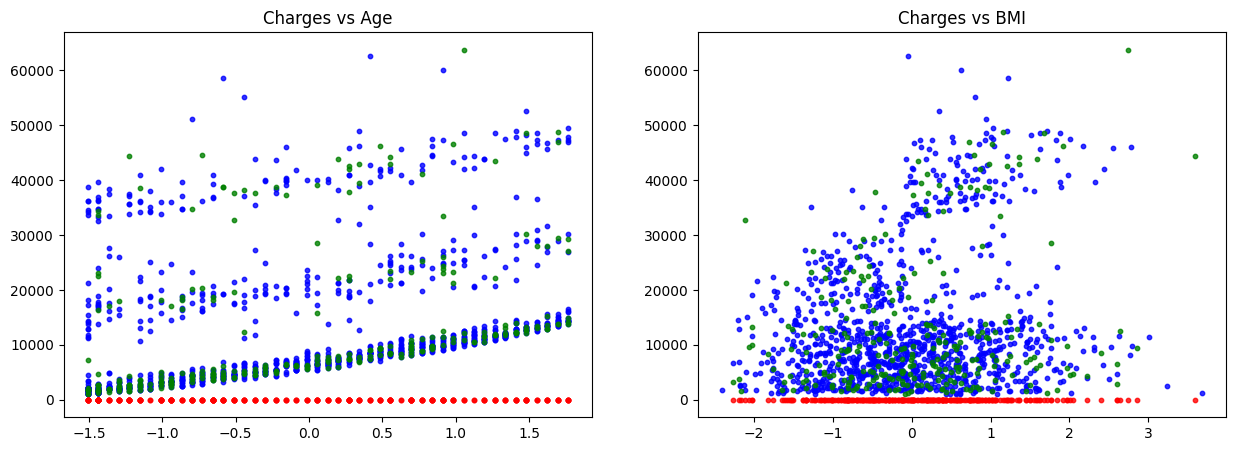

In [70]:
plot_predictions(predictions=y_preds)